In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
os.chdir("/Users/rishwanthpb/MLOPS/MLOPS_PROJECT")

In [4]:
FILES = [
    "2019-01", "2019-04", "2019-07", "2019-10",  # pre-COVID baseline
    "2020-01", "2020-04",                          # COVID collapse
    "2023-01", "2023-04", "2023-07", "2023-10",   # recent normal
]

In [5]:
def load_and_clean(ym):
    year, month = ym.split("-")
    start = f"{year}-{month}-01"
    # Get next month for date filter
    next_month = int(month) + 1
    next_year = int(year)
    if next_month > 12:
        next_month = 1
        next_year += 1
    end = f"{next_year}-{next_month:02d}-01"

    df = pd.read_parquet(f"data/raw/yellow_tripdata_{ym}.parquet")
    df = df[(df['tpep_pickup_datetime'] >= start) & (df['tpep_pickup_datetime'] < end)]
    df = df.drop(columns=['airport_fee', 'store_and_fwd_flag'], errors='ignore')
    df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
    df = df.dropna(subset=['passenger_count', 'RatecodeID'])
    df['ym'] = ym
    return df

In [6]:
all_dfs = []
for ym in FILES:
    print(f"Loading {ym}...")
    all_dfs.append(load_and_clean(ym))

df_all = pd.concat(all_dfs, ignore_index=True)
print("\nTotal shape:", df_all.shape)

Loading 2019-01...
Loading 2019-04...
Loading 2019-07...
Loading 2019-10...
Loading 2020-01...
Loading 2020-04...
Loading 2023-01...
Loading 2023-04...
Loading 2023-07...
Loading 2023-10...

Total shape: (47483050, 19)


Target variable

In [7]:
df_all['pickup_hour'] = df_all['tpep_pickup_datetime'].dt.floor('h')

demand = df_all.groupby(
    ['ym', 'PULocationID', 'pickup_hour']
).size().reset_index(name='demand')

print("Demand table shape:", demand.shape)
print(demand.head())

Demand table shape: (791986, 4)
        ym  PULocationID         pickup_hour  demand
0  2019-01             1 2019-01-01 02:00:00       1
1  2019-01             1 2019-01-01 05:00:00       1
2  2019-01             1 2019-01-01 06:00:00       1
3  2019-01             1 2019-01-01 08:00:00       2
4  2019-01             1 2019-01-01 10:00:00       4


In [8]:
max(demand['demand'])

1422

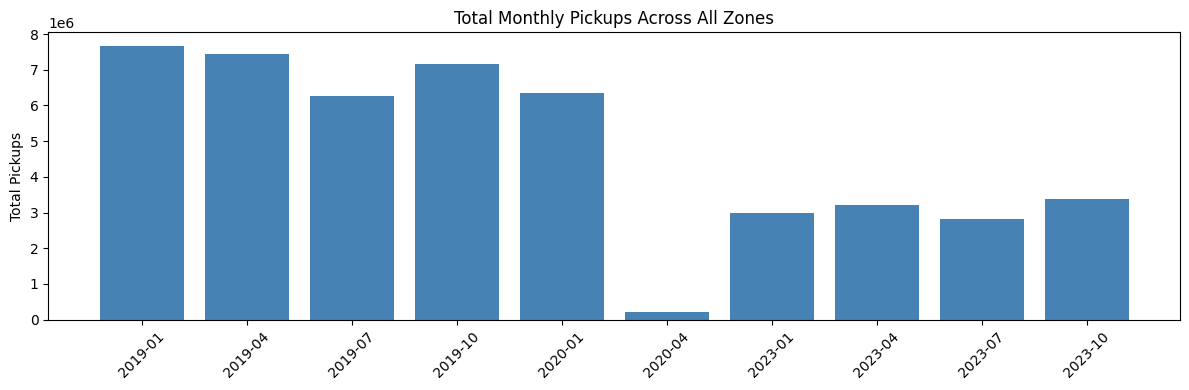

        ym   demand
0  2019-01  7667408
1  2019-04  7433180
2  2019-07  6276175
3  2019-10  7166865
4  2020-01  6339355
5  2020-04   218361
6  2023-01  2994975
7  2023-04  3197465
8  2023-07  2821963
9  2023-10  3367303


In [9]:
monthly_total = demand.groupby('ym')['demand'].sum().reset_index()
monthly_total = monthly_total.sort_values('ym')

plt.figure(figsize=(12, 4))
plt.bar(monthly_total['ym'], monthly_total['demand'], color='steelblue')
plt.xticks(rotation=45)
plt.title('Total Monthly Pickups Across All Zones')
plt.ylabel('Total Pickups')
plt.tight_layout()
plt.show()

print(monthly_total)

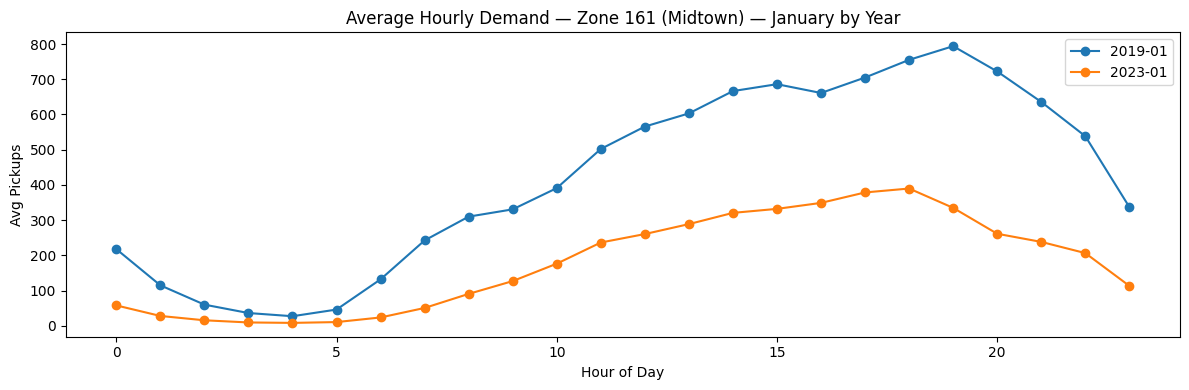

In [10]:
# Compare January across 2019, 2022, 2023 for zone 161
jan_years = demand[
    (demand['PULocationID'] == 161) &
    (demand['ym'].isin(['2019-01', '2022-01', '2023-01']))
].copy()

jan_years['hour'] = jan_years['pickup_hour'].dt.hour

hourly_avg = jan_years.groupby(['ym', 'hour'])['demand'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
for ym, group in hourly_avg.groupby('ym'):
    ax.plot(group['hour'], group['demand'], marker='o', label=ym)

ax.set_title('Average Hourly Demand — Zone 161 (Midtown) — January by Year')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Pickups')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
import json

# Use only 2019 data as the baseline (pre-COVID normal)
demand_2019 = demand[demand['ym'].str.startswith('2019')]

baseline = demand_2019.groupby('PULocationID')['demand'].agg(
    mean='mean',
    std='std',
    median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    p95=lambda x: x.quantile(0.95)
).reset_index()

print("Baseline stats shape:", baseline.shape)
print(baseline.head(10))

# Save to file
os.makedirs("data/processed", exist_ok=True)
baseline.to_csv("data/processed/zone_demand_baseline.csv", index=False)
print("\nBaseline saved to data/processed/zone_demand_baseline.csv")

Baseline stats shape: (263, 7)
   PULocationID       mean        std  median  p25   p75   p95
0             1   1.910201   1.236218     1.0  1.0   2.0   4.0
1             2   1.055556   0.333333     1.0  1.0   1.0   1.0
2             3   1.177874   0.474145     1.0  1.0   1.0   2.0
3             4  15.995215  15.087255    12.0  7.0  19.0  42.0
4             5   1.051724   0.258586     1.0  1.0   1.0   1.0
5             6   1.156250   0.443150     1.0  1.0   1.0   2.0
6             7  13.568767   7.142971    12.0  9.0  17.0  27.0
7             8   1.094118   0.311946     1.0  1.0   1.0   2.0
8             9   1.094851   0.367424     1.0  1.0   1.0   2.0
9            10   3.975040   3.108227     3.0  2.0   5.0  10.0

Baseline saved to data/processed/zone_demand_baseline.csv
